# Notebook 5 -- So sánh Logistic Regression, MLP, XGBoost và LightGBM

**Mục tiêu**
- Dựng lại `y_test` bằng cùng outer split chuẩn: `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`
- Load `y_prob` đã lưu trong `features/`
- So sánh 4 mô hình theo hai tầng:
  - `Threshold-free`: `PR-AUC`, `ROC-AUC`
  - `Threshold-based`: `Accuracy`, `Precision`, `Recall`, `F1-score`, `Confusion Matrix`
- Trực quan hóa kết quả bằng `matplotlib` để hỗ trợ viết báo cáo

**Protocol so sánh hiện tại**
- `Logistic Regression`: dùng threshold đã tune trong notebook 2
- `MLP`: dùng threshold đã tune trong notebook 4
- `XGBoost`, `LightGBM`: dùng threshold mặc định `0.5`
- Kết luận chính nên dựa vào `PR-AUC` và `ROC-AUC`

**Lưu ý**
- Notebook này không train lại mô hình, chỉ load artifact đã có

## 1. Import thư viện và thiết lập

In [88]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

SEED = 42
DATA_PATH = Path('../data/creditcard.csv')
GB_TEST_LABELS_PATH = Path('../features/y_test_gb.npy')
LR_META_PATH = Path('../models/fraud_lr_meta.json')
MLP_META_PATH = Path('../models/fraud_nn_meta.json')

PLOT_COLORS = {
    'Logistic Regression (ML)': '#1f77b4',
    'MLP (DL)': '#ff7f0e',
    'XGBoost (GB)': '#2ca02c',
    'LightGBM (GB)': '#d62728',
}

plt.style.use('seaborn-v0_8-whitegrid')


## 2. Dựng lại `y_test` chung

`y_test` được dựng lại bằng đúng outer split chuẩn giống các notebook huấn luyện. Nếu file `features/y_test_gb.npy` đã có, notebook sẽ kiểm tra thêm xem test labels của Gradient Boosting có khớp không.

In [89]:
def get_shared_test_labels(df):
    X = df.drop('Class', axis=1)
    y = df['Class']
    _, _, _, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    return y_test.to_numpy()


df = pd.read_csv(DATA_PATH)
y_test = get_shared_test_labels(df)

print(f'y_test shape: {y_test.shape}')
print(f'Fraud ratio on test: {y_test.mean()*100:.3f}%')

if GB_TEST_LABELS_PATH.exists():
    y_test_gb = np.load(GB_TEST_LABELS_PATH)
    same_labels = np.array_equal(y_test, y_test_gb)
    print(f'Compare with features/y_test_gb.npy: {same_labels}')
    if not same_labels:
        raise ValueError('y_test dựng lại không khớp với y_test_gb.npy. Hãy kiểm tra lại protocol split.')
else:
    print('features/y_test_gb.npy chưa có. Notebook sẽ dùng y_test dựng lại từ split chuẩn.')


y_test shape: (56962,)
Fraud ratio on test: 0.172%
Compare with features/y_test_gb.npy: True


## 3. Khai báo `MODEL_CONFIGS`

Threshold hiện tại được lấy theo output mới nhất của từng notebook:
- `LR`: threshold thắng từ notebook 2
- `MLP`: threshold thắng từ notebook 4
- `XGB`, `LGB`: threshold mặc định `0.5`

Nếu notebook 2 hoặc notebook 4 được train lại và chọn threshold mới, chỉ cần sửa lại cell này.

In [90]:
GB_DEFAULT_THRESHOLD = 0.5


def load_threshold_info(meta_path, model_label, fallback_threshold=0.5):
    if not meta_path.exists():
        return {
            'threshold': fallback_threshold,
            'threshold_source': f'Fallback default = {fallback_threshold} (missing {meta_path.name})',
            'threshold_type': 'fallback',
            'winner_context': 'metadata missing',
        }

    meta = json.loads(meta_path.read_text(encoding='utf-8'))
    winner = meta.get('winner', {})
    threshold_info = winner.get('threshold_info', {})
    threshold = threshold_info.get('threshold')

    if threshold is None:
        return {
            'threshold': fallback_threshold,
            'threshold_source': f'Fallback default = {fallback_threshold} ({meta_path.name} has no feasible threshold)',
            'threshold_type': 'fallback',
            'winner_context': winner.get('display_name') or winner.get('architecture') or model_label,
        }

    if 'display_name' in winner:
        winner_context = winner['display_name']
    elif 'architecture' in winner:
        winner_context = f"{winner['architecture']} ({winner.get('model_name', 'mlp')})"
    else:
        winner_context = model_label

    return {
        'threshold': float(threshold),
        'threshold_source': f'Auto-loaded from {meta_path.name}',
        'threshold_type': 'tuned',
        'winner_context': winner_context,
    }


lr_threshold_info = load_threshold_info(LR_META_PATH, 'Logistic Regression (ML)', fallback_threshold=0.5)
mlp_threshold_info = load_threshold_info(MLP_META_PATH, 'MLP (DL)', fallback_threshold=0.5)

MODEL_CONFIGS = [
    {
        'key': 'lr',
        'display_name': 'Logistic Regression (ML)',
        'family': 'Machine Learning',
        'prob_path': Path('../features/lr_y_prob.npy'),
        'threshold': lr_threshold_info['threshold'],
        'threshold_source': lr_threshold_info['threshold_source'],
        'threshold_type': lr_threshold_info['threshold_type'],
        'winner_context': lr_threshold_info['winner_context'],
    },
    {
        'key': 'mlp',
        'display_name': 'MLP (DL)',
        'family': 'Deep Learning',
        'prob_path': Path('../features/nn_y_prob.npy'),
        'threshold': mlp_threshold_info['threshold'],
        'threshold_source': mlp_threshold_info['threshold_source'],
        'threshold_type': mlp_threshold_info['threshold_type'],
        'winner_context': mlp_threshold_info['winner_context'],
    },
    {
        'key': 'xgb',
        'display_name': 'XGBoost (GB)',
        'family': 'Gradient Boosting',
        'prob_path': Path('../features/xgb_y_prob.npy'),
        'threshold': GB_DEFAULT_THRESHOLD,
        'threshold_source': 'Default threshold = 0.5 from notebook 3 protocol',
        'threshold_type': 'default',
        'winner_context': 'threshold not tuned in notebook 3',
    },
    {
        'key': 'lgb',
        'display_name': 'LightGBM (GB)',
        'family': 'Gradient Boosting',
        'prob_path': Path('../features/lgb_y_prob.npy'),
        'threshold': GB_DEFAULT_THRESHOLD,
        'threshold_source': 'Default threshold = 0.5 from notebook 3 protocol',
        'threshold_type': 'default',
        'winner_context': 'threshold not tuned in notebook 3',
    },
]

model_configs_df = pd.DataFrame([
    {
        'Model': cfg['display_name'],
        'Family': cfg['family'],
        'Probability file': str(cfg['prob_path']),
        'Threshold': cfg['threshold'],
        'Threshold type': cfg['threshold_type'],
        'Threshold source': cfg['threshold_source'],
        'Winner context': cfg['winner_context'],
    }
    for cfg in MODEL_CONFIGS
])
display(model_configs_df)


,Model,Family,Probability file,Threshold,Threshold type,Threshold source,Winner context
0,Logistic Regression (ML),Machine Learning,..\features\lr_y_prob.npy,0.999388,tuned,Auto-loaded from fraud_lr_meta.json,LR + class_weight=balanced | C=1
1,MLP (DL),Deep Learning,..\features\nn_y_prob.npy,0.612247,tuned,Auto-loaded from fraud_nn_meta.json,wide (wide_mlp)
2,XGBoost (GB),Gradient Boosting,..\features\xgb_y_prob.npy,0.500000,default,Default threshold = 0.5 from notebook 3 protocol,threshold not tuned in notebook 3
3,LightGBM (GB),Gradient Boosting,..\features\lgb_y_prob.npy,0.500000,default,Default threshold = 0.5 from notebook 3 protocol,threshold not tuned in notebook 3


## 4. Load xác suất dự đoán từ `features/`

Cell này sẽ load các file `y_prob` đang có. Nếu thiếu file nào, notebook chỉ ghi nhận là `missing` để bạn bổ sung artifact sau.

In [91]:
def load_probability_outputs(model_configs, y_true):
    available_models = []
    missing_files = []

    for cfg in model_configs:
        if cfg['prob_path'].exists():
            y_prob = np.load(cfg['prob_path'])
            if y_prob.shape != y_true.shape:
                raise ValueError(
                    f"{cfg['prob_path']} có shape {y_prob.shape}, không khớp y_test {y_true.shape}"
                )
            available_models.append({**cfg, 'y_prob': y_prob})
        else:
            missing_files.append(str(cfg['prob_path']))

    return available_models, missing_files


available_models, missing_files = load_probability_outputs(MODEL_CONFIGS, y_test)

print(f'Available probability files: {len(available_models)}/{len(MODEL_CONFIGS)}')
for cfg in available_models:
    print(f"- {cfg['display_name']}: {cfg['prob_path']}")

if missing_files:
    print('\nMissing files:')
    for path in missing_files:
        print(f'- {path}')
else:
    print('\nAll probability files are available.')


Available probability files: 4/4
- Logistic Regression (ML): ..\features\lr_y_prob.npy
- MLP (DL): ..\features\nn_y_prob.npy
- XGBoost (GB): ..\features\xgb_y_prob.npy
- LightGBM (GB): ..\features\lgb_y_prob.npy

All probability files are available.


## 5. Hàm đánh giá chung

In [92]:
def evaluate_from_probabilities(y_true, y_prob, model_name, threshold, threshold_source, threshold_type):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)

    return {
        'Model': model_name,
        'Threshold': threshold,
        'Threshold Type': threshold_type,
        'Threshold Source': threshold_source,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'TP': int(cm[1, 1]),
        'FP': int(cm[0, 1]),
        'TN': int(cm[0, 0]),
        'FN': int(cm[1, 0]),
        'y_prob': y_prob,
        'y_pred': y_pred,
        'confusion_matrix': cm,
        'roc_curve': (fpr, tpr),
        'pr_curve': (recall_curve, precision_curve),
    }


model_results = []
for cfg in available_models:
    model_results.append(
        evaluate_from_probabilities(
            y_test,
            cfg['y_prob'],
            cfg['display_name'],
            cfg['threshold'],
            cfg['threshold_source'],
            cfg['threshold_type'],
        )
    )

comparison_df = pd.DataFrame([
    {
        k: v for k, v in result.items()
        if k not in ['y_prob', 'y_pred', 'confusion_matrix', 'roc_curve', 'pr_curve']
    }
    for result in model_results
])

threshold_free_df = comparison_df[[
    'Model', 'ROC-AUC', 'PR-AUC'
]].copy() if not comparison_df.empty else pd.DataFrame(columns=['Model', 'ROC-AUC', 'PR-AUC'])

threshold_based_df = comparison_df[[
    'Model', 'Threshold', 'Threshold Type', 'Accuracy', 'Precision', 'Recall',
    'F1-score', 'TP', 'FP', 'TN', 'FN'
]].copy() if not comparison_df.empty else pd.DataFrame(
    columns=['Model', 'Threshold', 'Threshold Type', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'TP', 'FP', 'TN', 'FN']
)

print(f'Models ready for comparison: {len(model_results)}')


Models ready for comparison: 4


## 6. Threshold-free metrics

`PR-AUC` và `ROC-AUC` là phần so sánh chính vì chúng dùng trực tiếp xác suất dự đoán và không phụ thuộc threshold.

In [93]:
if threshold_free_df.empty:
    print('Chưa có model nào đủ artifact để đánh giá threshold-free metrics.')
else:
    display(threshold_free_df.sort_values('PR-AUC', ascending=False))


,Model,ROC-AUC,PR-AUC
3,LightGBM (GB),0.978178,0.879367
2,XGBoost (GB),0.978862,0.876290
1,MLP (DL),0.978407,0.847263
0,Logistic Regression (ML),0.973955,0.716957


## 7. Threshold-based metrics

Bảng này phản ánh operating point hiện tại của từng pipeline. Lưu ý rằng threshold policy giữa 4 model chưa đồng nhất hoàn toàn.

In [94]:
threshold_policy_df = comparison_df[[
    'Model', 'Threshold', 'Threshold Type', 'Threshold Source'
]].copy() if not comparison_df.empty else pd.DataFrame(
    columns=['Model', 'Threshold', 'Threshold Type', 'Threshold Source']
)

if threshold_policy_df.empty:
    print('Chưa có model nào đủ artifact để đánh giá threshold-based metrics.')
else:
    print('Threshold policy used in this comparison:')
    display(threshold_policy_df)
    display(threshold_based_df)


Threshold policy used in this comparison:


,Model,Threshold,Threshold Type,Threshold Source
0,Logistic Regression (ML),0.999388,tuned,Auto-loaded from fraud_lr_meta.json
1,MLP (DL),0.612247,tuned,Auto-loaded from fraud_nn_meta.json
2,XGBoost (GB),0.500000,default,Default threshold = 0.5 from notebook 3 protocol
3,LightGBM (GB),0.500000,default,Default threshold = 0.5 from notebook 3 protocol


,Model,Threshold,Threshold Type,Accuracy,Precision,Recall,F1-score,TP,FP,TN,FN
0,Logistic Regression (ML),0.999388,tuned,0.999017,0.669355,0.846939,0.747748,83,41,56823,15
1,MLP (DL),0.612247,tuned,0.999034,0.674797,0.846939,0.751131,83,40,56824,15
2,XGBoost (GB),0.500000,default,0.999526,0.873684,0.846939,0.860104,83,12,56852,15
3,LightGBM (GB),0.500000,default,0.999508,0.857143,0.857143,0.857143,84,14,56850,14


## 8. Precision-Recall Curve của các mô hình

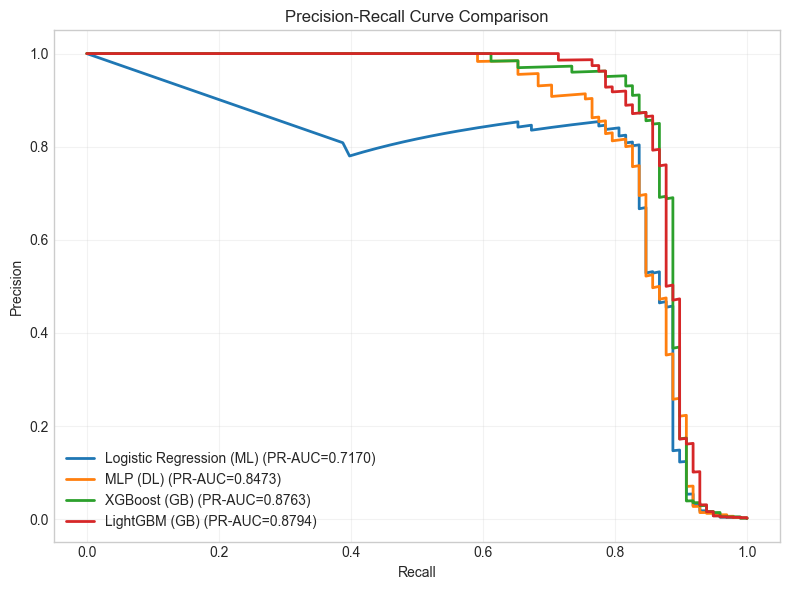

In [95]:
if not model_results:
    print('Chưa có model nào để vẽ Precision-Recall Curve.')
else:
    plt.figure(figsize=(8, 6))
    for result in model_results:
        recall_curve, precision_curve = result['pr_curve']
        plt.plot(
            recall_curve,
            precision_curve,
            linewidth=2,
            label=f"{result['Model']} (PR-AUC={result['PR-AUC']:.4f})",
            color=PLOT_COLORS.get(result['Model'], None),
        )

    plt.title('Precision-Recall Curve Comparison')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 9. ROC Curve của các mô hình

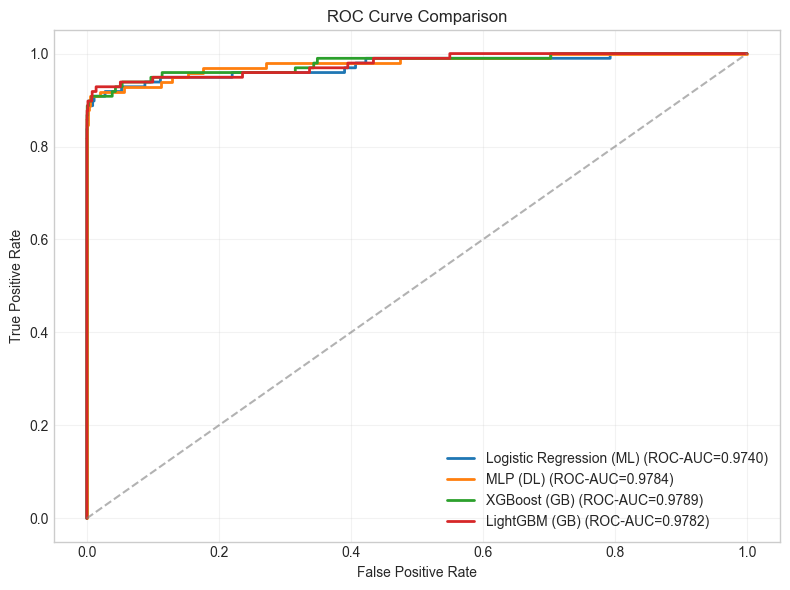

In [96]:
if not model_results:
    print('Chưa có model nào để vẽ ROC Curve.')
else:
    plt.figure(figsize=(8, 6))
    for result in model_results:
        fpr, tpr = result['roc_curve']
        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{result['Model']} (ROC-AUC={result['ROC-AUC']:.4f})",
            color=PLOT_COLORS.get(result['Model'], None),
        )

    plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
    plt.title('ROC Curve Comparison')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 10. Bar chart so sánh `PR-AUC` và `ROC-AUC`

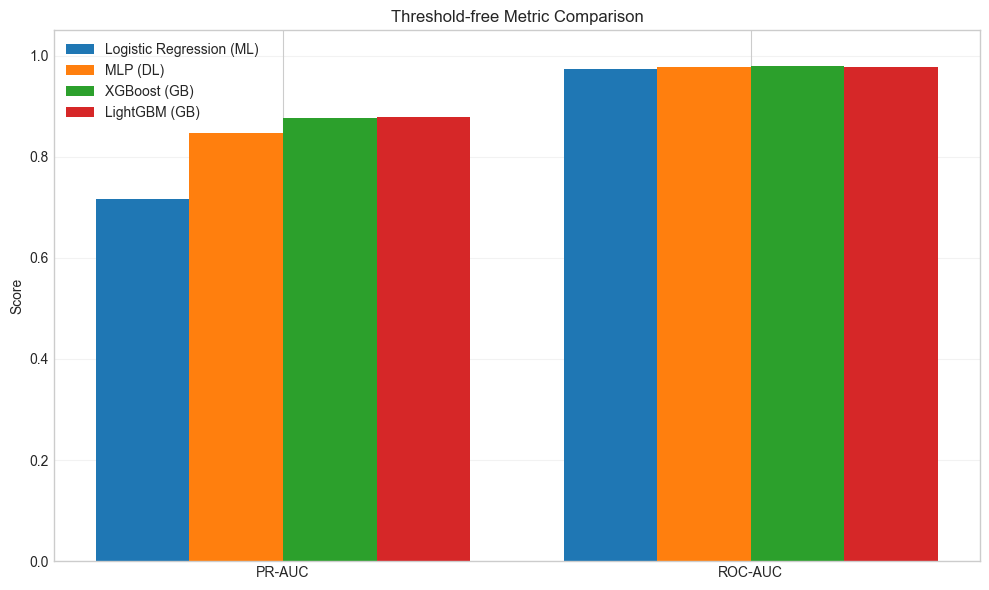

In [97]:
if threshold_free_df.empty:
    print('Chưa có đủ dữ liệu để vẽ bar chart threshold-free metrics.')
else:
    metric_names = ['PR-AUC', 'ROC-AUC']
    x = np.arange(len(metric_names))
    width = 0.8 / max(len(model_results), 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for idx, result in enumerate(model_results):
        values = [result[m] for m in metric_names]
        offset = (idx - (len(model_results) - 1) / 2) * width
        ax.bar(
            x + offset,
            values,
            width,
            label=result['Model'],
            color=PLOT_COLORS.get(result['Model'], None),
        )

    ax.set_title('Threshold-free Metric Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


## 11. Grouped bar chart cho `Precision`, `Recall`, `F1-score`

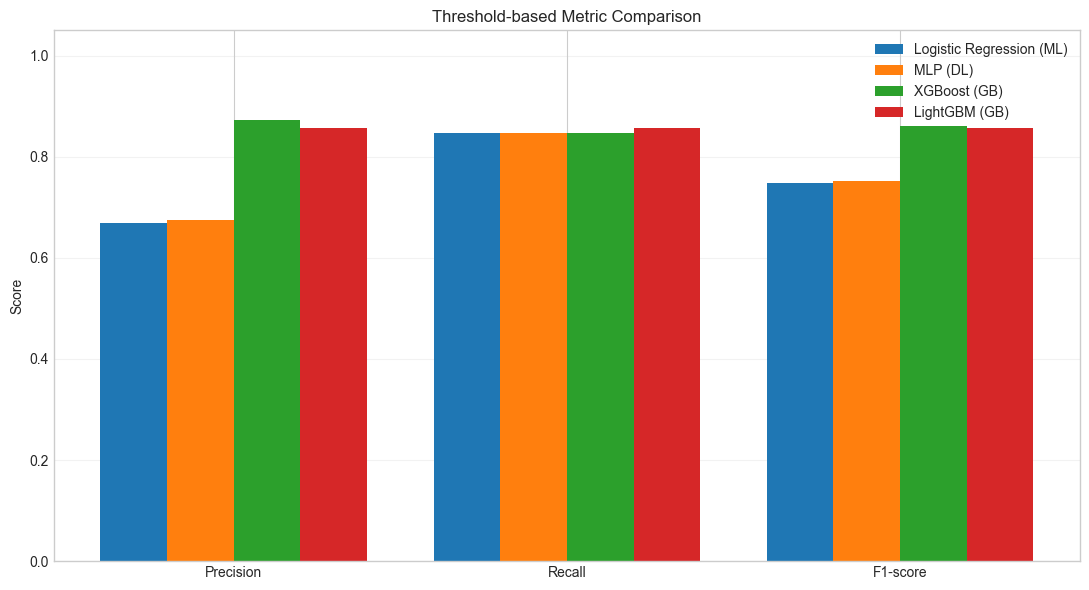

In [98]:
if threshold_based_df.empty:
    print('Chưa có đủ dữ liệu để vẽ grouped bar chart threshold-based metrics.')
else:
    metric_names = ['Precision', 'Recall', 'F1-score']
    x = np.arange(len(metric_names))
    width = 0.8 / max(len(model_results), 1)

    fig, ax = plt.subplots(figsize=(11, 6))
    for idx, result in enumerate(model_results):
        values = [result[m] for m in metric_names]
        offset = (idx - (len(model_results) - 1) / 2) * width
        ax.bar(
            x + offset,
            values,
            width,
            label=result['Model'],
            color=PLOT_COLORS.get(result['Model'], None),
        )

    ax.set_title('Threshold-based Metric Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


## 12. Ma trận nhầm lẫn của các mô hình

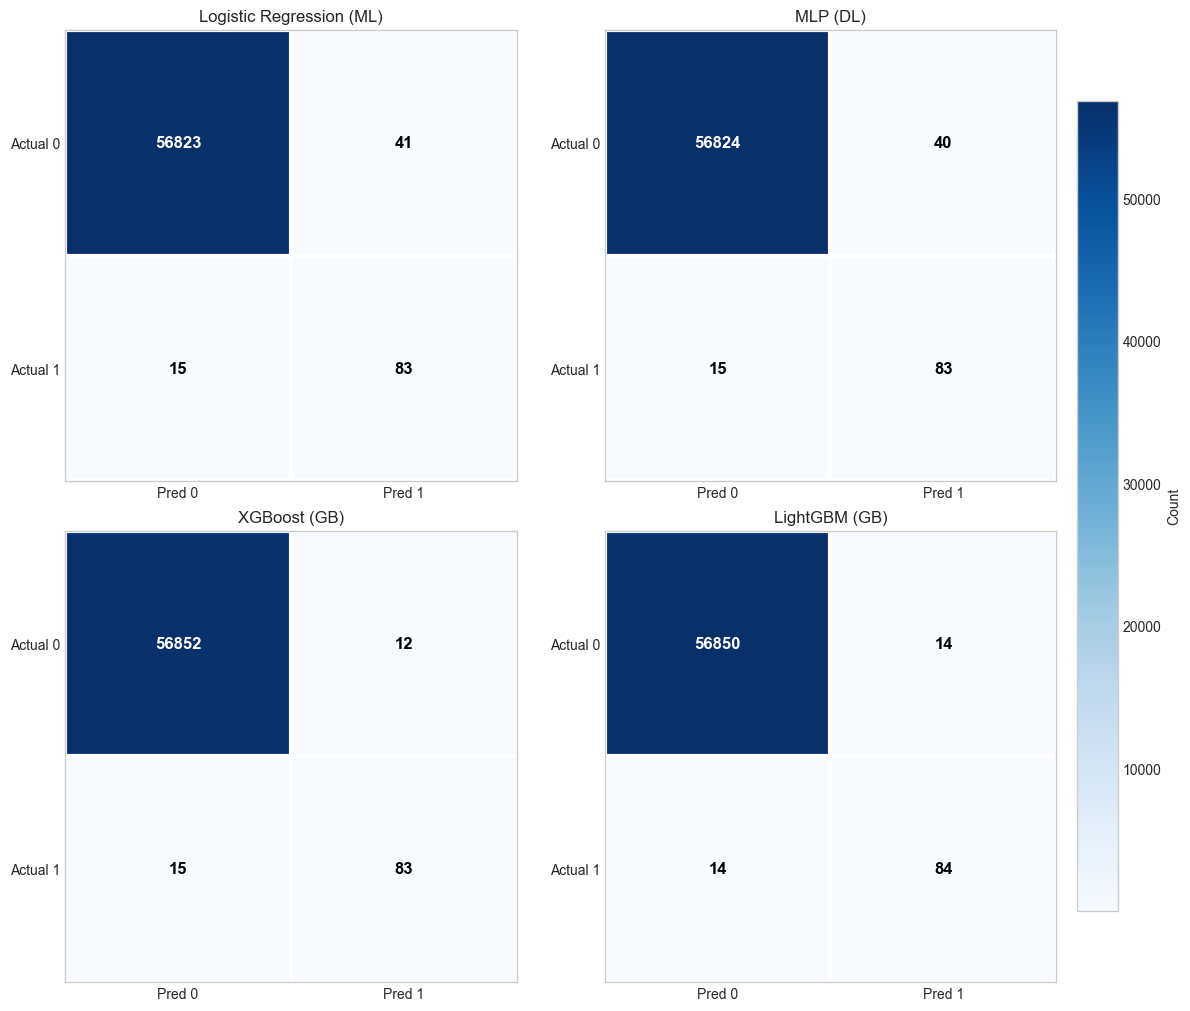

In [103]:
if not model_results:
    print('Chưa có model nào để vẽ confusion matrix.')
else:
    n_models = len(model_results)
    n_cols = 2
    n_rows = math.ceil(n_models / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, result in zip(axes, model_results):
        cm = result['confusion_matrix']

        im = ax.imshow(cm, cmap='Blues', interpolation='nearest')

        ax.set_title(result['Model'])
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Pred 0', 'Pred 1'])
        ax.set_yticklabels(['Actual 0', 'Actual 1'])

        # Chia rõ 4 ô
        ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
        ax.grid(which='minor', color='white', linestyle='-', linewidth=3)
        ax.tick_params(which='minor', bottom=False, left=False)
        ax.grid(False)

        threshold = cm.max() / 2.0
        for i in range(2):
            for j in range(2):
                color = 'white' if cm[i, j] > threshold else 'black'
                ax.text(
                    j, i, f'{cm[i, j]}',
                    ha='center', va='center',
                    color=color, fontsize=12, fontweight='bold'
                )

    for ax in axes[n_models:]:
        ax.axis('off')

    # Tạo thanh màu riêng, không đè lên subplot
    cbar = fig.colorbar(
        im,
        ax=axes[:n_models],
        location='right',
        shrink=0.85,
        pad=0.02
    )
    cbar.ax.set_ylabel('Count', rotation=90)

    plt.show()


## 13. Histogram / density của `y_prob` theo hai lớp `Fraud` / `Non-Fraud`

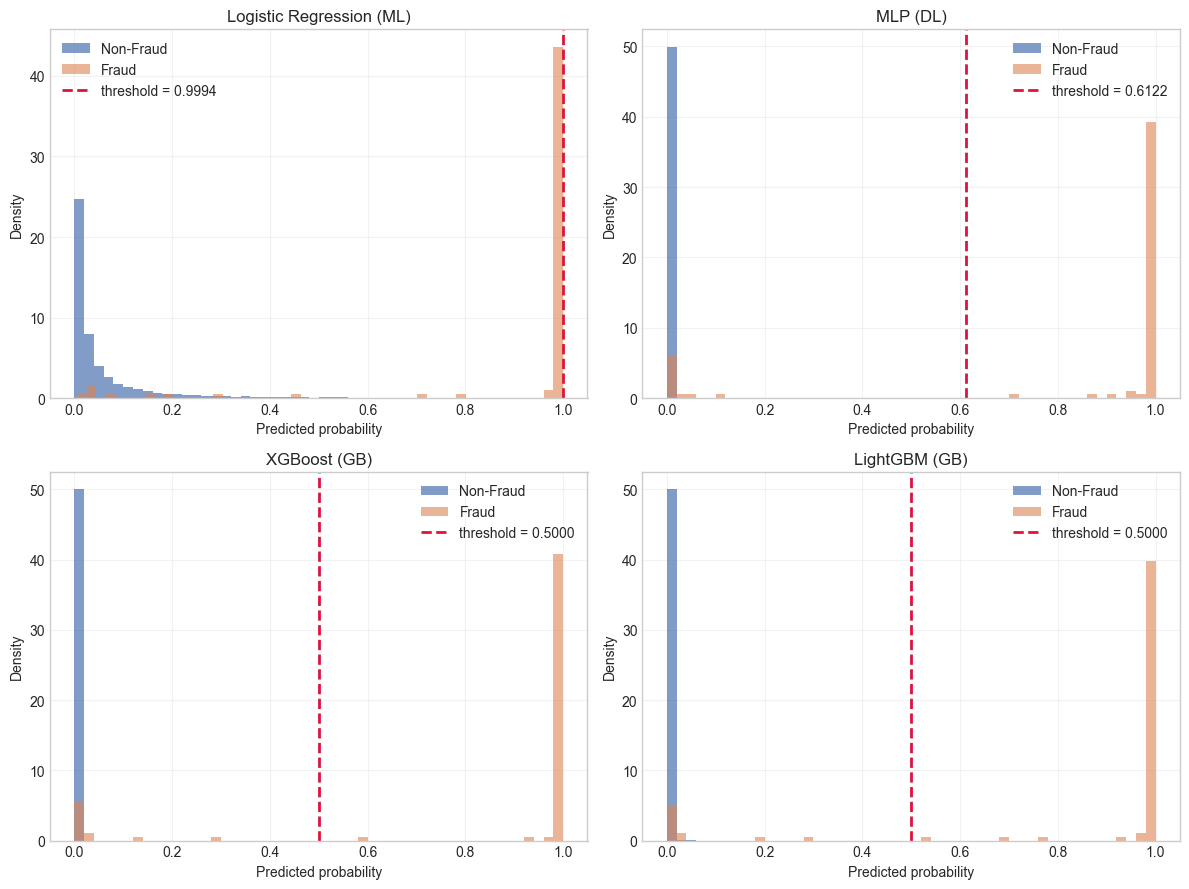

In [100]:
if not model_results:
    print('Chưa có model nào để vẽ phân phối y_prob.')
else:
    n_models = len(model_results)
    n_cols = 2
    n_rows = math.ceil(n_models / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.5 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, result in zip(axes, model_results):
        y_prob = result['y_prob']
        ax.hist(y_prob[y_test == 0], bins=50, density=True, alpha=0.70, color='#4c72b0', label='Non-Fraud')
        ax.hist(y_prob[y_test == 1], bins=50, density=True, alpha=0.60, color='#dd8452', label='Fraud')
        ax.axvline(result['Threshold'], color='crimson', linestyle='--', linewidth=2, label=f"threshold = {result['Threshold']:.4f}")
        ax.set_title(result['Model'])
        ax.set_xlabel('Predicted probability')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(alpha=0.25)

    for ax in axes[n_models:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## 14. Kết luận tổng thể

In [101]:
if comparison_df.empty:
    print('Chưa có đủ artifact để kết luận. Hãy bổ sung các file y_prob vào thư mục features/.')
else:
    best_by_pr_auc = comparison_df.loc[comparison_df['PR-AUC'].idxmax()]
    best_by_roc_auc = comparison_df.loc[comparison_df['ROC-AUC'].idxmax()]
    best_by_recall = comparison_df.loc[comparison_df['Recall'].idxmax()]
    best_by_f1 = comparison_df.loc[comparison_df['F1-score'].idxmax()]

    print('Kết luận tự động từ các artifact hiện có:')
    print(f"- Model tốt nhất theo PR-AUC : {best_by_pr_auc['Model']} ({best_by_pr_auc['PR-AUC']:.4f})")
    print(f"- Model tốt nhất theo ROC-AUC: {best_by_roc_auc['Model']} ({best_by_roc_auc['ROC-AUC']:.4f})")
    print(f"- Model tốt nhất theo Recall : {best_by_recall['Model']} ({best_by_recall['Recall']:.4f})")
    print(f"- Model tốt nhất theo F1     : {best_by_f1['Model']} ({best_by_f1['F1-score']:.4f})")

    print('\nGợi ý đọc kết quả cho báo cáo:')
    print('- Kết luận chính nên dựa vào PR-AUC, vì dữ liệu fraud rất mất cân bằng.')
    print('- ROC-AUC là chỉ số bổ sung để đánh giá khả năng xếp hạng tổng quát.')
    print('- Precision / Recall / F1 phản ánh operating point hiện tại của từng pipeline.')
    print('- Vì LR và MLP dùng threshold tuned, còn XGB và LGB đang dùng threshold 0.5, threshold-based metrics chưa hoàn toàn apples-to-apples.')

    if missing_files:
        print('\nSo sánh hiện chưa hoàn chỉnh vì còn thiếu artifact:')
        for path in missing_files:
            print(f'- {path}')

Kết luận tự động từ các artifact hiện có:
- Model tốt nhất theo PR-AUC : LightGBM (GB) (0.8794)
- Model tốt nhất theo ROC-AUC: XGBoost (GB) (0.9789)
- Model tốt nhất theo Recall : LightGBM (GB) (0.8571)
- Model tốt nhất theo F1     : XGBoost (GB) (0.8601)

Gợi ý đọc kết quả cho báo cáo:
- Kết luận chính nên dựa vào PR-AUC, vì dữ liệu fraud rất mất cân bằng.
- ROC-AUC là chỉ số bổ sung để đánh giá khả năng xếp hạng tổng quát.
- Precision / Recall / F1 phản ánh operating point hiện tại của từng pipeline.
- Vì LR và MLP dùng threshold tuned, còn XGB và LGB đang dùng threshold 0.5, threshold-based metrics chưa hoàn toàn apples-to-apples.
